
# Lab 8: Monte Carlo Markov Chain (MCMC)

## Modelo de Ising 2D

Como aplicación de la distribución canónica en `Física estadística` tenemos el modelo de **Ising**.

Para el caso de un material paramagnético de átomos de spin $1/2$ y momento magnetico $\mu_0$ en presencia de un campo magnético externo $H$, se ha determinado experimentalmente que la magnetización media depende del campo magnético y la temperatura del material. Consultar: (https://en.wikipedia.org/wiki/Ising_model)

**Exercise**: Considere un sistema compuesto por $N$ átomos no interactuantes en un material 2D, a una temperatura $T$ y en presencia de un campo magnético externo $H$ que está orientado en cierta dirección fija respecto al material:

<img src="https://upload.wikimedia.org/wikipedia/commons/f/fe/2D_ising_model_on_lattice.svg" width="550">

1. Realizar la simulación mediante el uso del método de Metrópolis Monte Carlo para este sistema. En este caso, visitar todos los
posibles spines de la red cristalina del material e intentear inversiones bajo condiciones adecuadas de energía y estabilidad del sistema:

    Algoritmo:
    * *Selecciona** un microestado $x$ inicial de manera aleatoria para todos los espines de la red (spin: +1 arriba y -1 abajo). Esta es la configuración inicial.
    * *Visitar* aleatoriamente un punto de la red y hacer una inversión de su espín... configuración $x'$.
    * *Aceptación*: Comprobar la energia $E$ del sistema. 
            Si la energía disminuye se acepta la nueva configuración $x'$. 
            Si aumenta, se debe generar un número aleatorio entre $[0,1]$. Si este número es mayor que el factor de Boltzman $\mathcal{P}(E,T)=e^{-E/(KT)}$ se rechaza $x'$. De lo contrario se acepta la nueva configuración $x'$.
    * *Repetir* los pasos anteriores.
    * *Finalizar*: Cuando llegue al creterio de finalización se debe terminar.


2. Graficar la Magnetización media del material vs el campo magnetico para tres temperaturas reducidas (H/T) con $T=\{5,15,20\}$ K (Kelvin) y un campo variable $-30\,G < H < +30\,G$ (Gauss), .  Monstrar que la distribución canónica de la magnetización clásica es muy acertada (consultar). 
3. Investigar el resultado analítico para este sistema 2D y comparar con la simulación de MC. ¿Qué tan precisa es la simulación? Explique.

La energía potencial $E$ de un dipolo magnético (con momento magnético $\vec{\mu}$) inmerso en un campo magnético externo $\vec{H}$ está dada por el producto 

$$E = -\vec{\mu} \cdot \vec{H}$$

Dada la variable de espín $s_i$ se deduce $E_0 = - \mu_0 H s_i$. Al invertir el espín de la particula $ij$ se obtiene 
$$\Delta E = - \mu_0 H (-s_i) - (- \mu_0 H s_i) = 2 \mu_0 H s_i$$

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def metropolis_mc(L, T, H, mu=1.0, kb=1.0, steps=100_000):
    """
    Simulación de Monte Carlo para un sistema 2D de espines no interactuantes.
    L: Tamaño de la red (L x L)
    T: Temperatura
    H: Campo magnético
    """
    # 1. Configuración inicial aleatoria (+1 o -1)
    grid = np.random.choice([-1, 1], size=(L, L))
    N = L * L
    
    # Para estabilizar el sistema (termalización), descartamos los primeros pasos
    termalization_steps = int(0.1 * steps)
    
    magnetization_sum = 0
    samples = 0
    
    for step in range(steps):
        # 2. Visitar aleatoriamente un punto de la red
        i, j = np.random.randint(0, L, size=2)
        spin = grid[i, j]
        
        # 3. Comprobar energía (solo importa el término del campo externo al no haber interacción)
        dE = 2.0 * mu * H * spin # -> Este si es dE?
        
        # Aceptación de Metrópolis
        if dE < 0:
            grid[i, j] = -spin
        else:
            r = np.random.rand()
            if r < np.exp(-dE / (kb * T)):
                grid[i, j] = -spin
                
        # Tomar medidas después de la termalización para evitar el sesgo inicial
        if step > termalization_steps:
            magnetization_sum += np.sum(grid)
            samples += 1
            
    # Retorna la magnetización media por átomo y por unidad de tiempo
    return magnetization_sum / (samples * N)

Para simplificar las unidades $\mu_0 = k_B = 1.0$.

La solución analitica viene dado por

$$\langle M \rangle = N \mu_0 \tanh\left(\frac{\mu_0 H}{k_B T}\right)$$

y la solución clásica es propuesta por Langevin y tiene la forma de:

$$\langle M \rangle = N \mu_0 \left( \coth(x) - \frac{1}{x} \right)$$

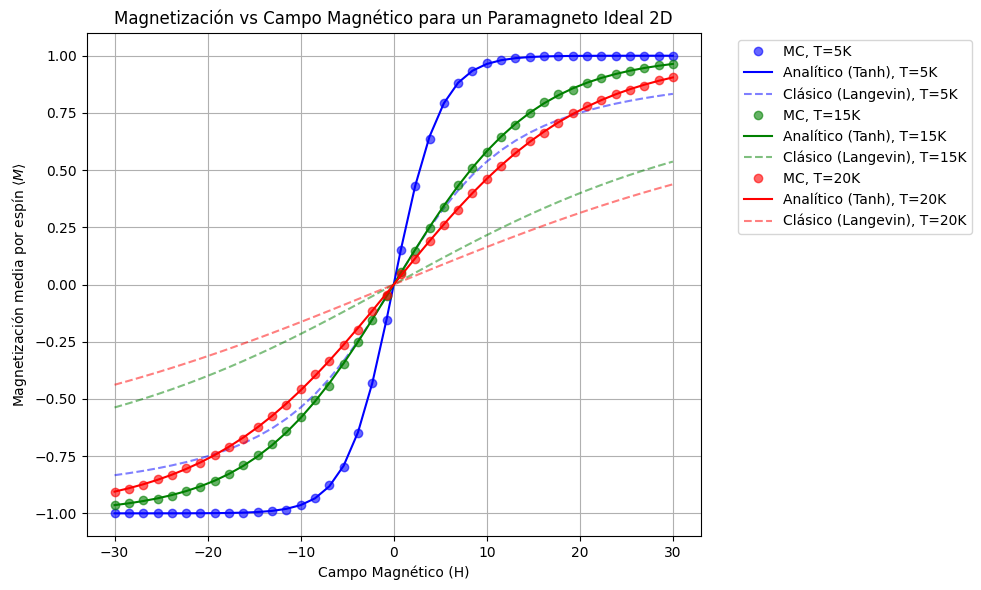

In [5]:
# Parámetros del ejercicio
L = 20  # Red de 20x20 = 400 átomos
T_values = [5, 15, 20]
H_values = np.linspace(-30, 30, 40)

# Diccionarios para almacenar resultados
M_mc = {T: [] for T in T_values}
M_analytical = {T: [] for T in T_values}
M_classical = {T: [] for T in T_values}

for T in T_values:
    for H in H_values:
        # Resultado de Monte Carlo
        M_mc[T].append(metropolis_mc(L, T, H, steps=50000))
        
        # 3. Resultado Analítico Exacto (Mecánica Estadística Cuántica, spin 1/2)
        M_analytical[T].append(np.tanh(H / T))
        
        # Distribución canónica de magnetización clásica (Función de Langevin)
        # L(x) = coth(x) - 1/x
        x = H / T
        if x == 0:
            M_classical[T].append(0)
        else:
            M_classical[T].append((1/np.tanh(x)) - (1/x))

# Graficar
plt.figure(figsize=(10, 6))

colors = {5: 'blue', 15: 'green', 20: 'red'}

for T in T_values:
    plt.plot(H_values, M_mc[T], 'o', color=colors[T], label=f'MC, T={T}K', alpha=0.6)
    plt.plot(H_values, M_analytical[T], '-', color=colors[T], label=f'Analítico (Tanh), T={T}K')
    plt.plot(H_values, M_classical[T], '--', color=colors[T], label=f'Clásico (Langevin), T={T}K', alpha=0.5)

plt.xlabel('Campo Magnético (H)')
plt.ylabel('Magnetización media por espín $\\langle M \\rangle$')
plt.title('Magnetización vs Campo Magnético para un Paramagneto Ideal 2D')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

A mi parecer el modelo clásico falla en predecir el comportamiento real, así que es falso afirmar que es muy acertada. Por otro lado note que la predicción del modelo MCMC es practicamente identica a la curva teorica de magnetización.

NOta 4.8 mmuy bien. 

No grafica la magnetización.Faltó considerar el número N, el magnethon de Bohr $\mu_0$... esta bien ponerlos 1 para correr la simulación, pero al finla toca recuperar el valor teórico....